# Feature Engineering Analysis

## Overview

This notebook explores potential feature engineering ideas for customer churn prediction.

The analysis focuses on proposing and evaluating new features based on customer behavior
and their relationship with the target variable (`Churn`).

All features created here are temporary and used for analysis only.
Approved features will be implemented later in the production pipeline.

## Setup & Data Loading

In [4]:
import sys
from pathlib import Path

# Add project root to PYTHONPATH
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils.config import PROCESSED_DATA_PATH

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [6]:
df = pd.read_csv(PROCESSED_DATA_PATH / "telco_customer_churn_encoded.csv")

## Feature Engineering Analysis


### Feature: tenure_bin
- Hypothysis: Customers with shorter tenure are more likely to churn than long-term customers.

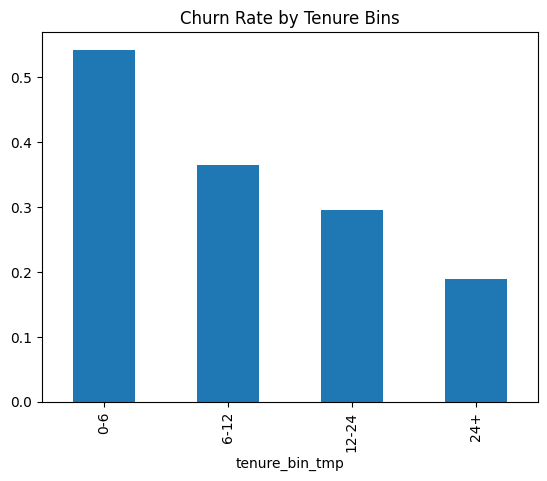

In [12]:
df["tenure_bin_tmp"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 60],
    labels=["0-6", "6-12", "12-24", "24+"],
    right=False
)
df.groupby("tenure_bin_tmp", observed=False)["Churn"].mean().plot(kind="bar")
plt.title("Churn Rate by Tenure Bins")
plt.show()

In [13]:
df["tenure_bin_tmp"].value_counts(normalize=True)

tenure_bin_tmp
24+      0.439568
0-6      0.246583
12-24    0.188309
6-12     0.125540
Name: proportion, dtype: float64

#### Observation:
* Churn rate decreases monotonically with increasing tenure.
* Higher tenure categories, especially 24+ months, show strong customer stability.

#### Decision:
* Keep tenure_bin as a lifecycle feature that effectively captures customer tenure stages.


### Feature: num_active_services
* Hypothysis: Customers subscribed to more services are less likely to churn due to higher switching costs.

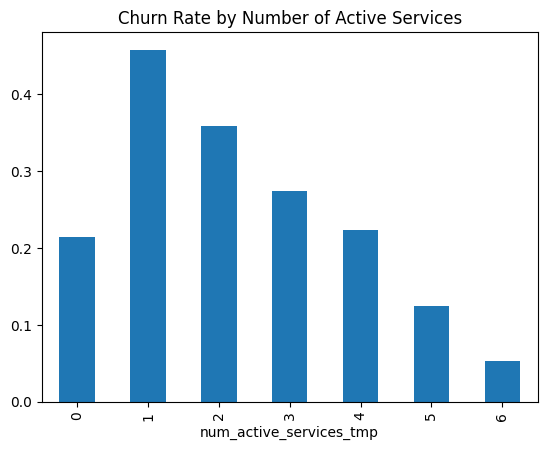

In [17]:
service_cols = [
    "OnlineSecurity_Yes",
    "OnlineBackup_Yes",
    "DeviceProtection_Yes",
    "TechSupport_Yes",
    "StreamingTV_Yes",
    "StreamingMovies_Yes"
]

df["num_active_services_tmp"] = df[service_cols].sum(axis=1)
df.groupby("num_active_services_tmp", observed=False)["Churn"].mean().plot(kind="bar")
plt.title("Churn Rate by Number of Active Services")
plt.show()

#### Observation:
- Churn rate peaks at customers with a single active service,
- while customers with no additional services exhibit lower churn.
- As the number of active services increases beyond one,
- churn rate decreases consistently, indicating stronger customer commitment.

#### Decision:
- Keep num_active_services as a behavioral feature reflecting service adoption
and customer commitment.


### Feature: is_month_to_month
- Hypothysis: Customers on month-to-month contracts are more likely to churn due to lower commitment.

In [35]:
contract_cols = [col for col in df.columns if col.startswith("Contract_")]
contract_cols

['Contract_One year', 'Contract_Two year']

Text(0.5, 1.0, 'Churn Rate by Month-to-Month Contract Status')

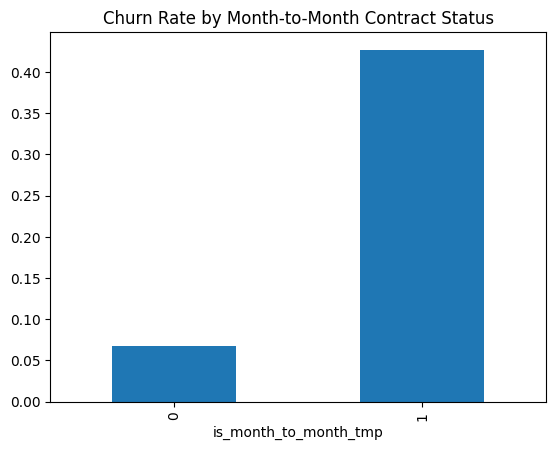

In [36]:
df["is_month_to_month_tmp"] = (df[contract_cols].sum(axis=1) == 0).astype(int)
df.groupby("is_month_to_month_tmp", observed=False)["Churn"].mean().plot(kind="bar")
plt.title("Churn Rate by Month-to-Month Contract Status")

In [25]:
df["is_month_to_month_tmp"].value_counts(normalize=True)

is_month_to_month_tmp
1    0.550192
0    0.449808
Name: proportion, dtype: float64

#### Observation:
- Customers on month-to-month contracts exhibit significantly higher churn rates, compared to customers with longer-term contracts, indicating lower commitment
and higher sensitivity to switching.

#### Decision:
- Keep is_month_to_month as a strong commitment-based feature for churn prediction.

### Feature: is_auto_payment
- Hypothysis: Customers using automatic payment methods are less likely to churn
due to higher payment consistency and lower friction.

In [32]:
[col for col in df.columns if col.startswith("PaymentMethod_")]


['PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

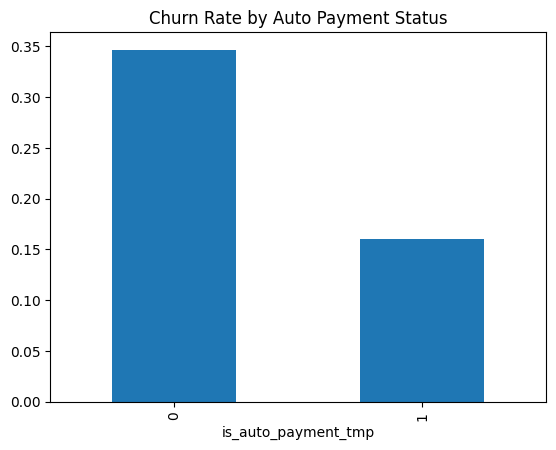

In [34]:
not_auto = [
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
    ]

df["is_auto_payment_tmp"] = (
    df[not_auto].sum(axis=1) == 0
).astype(int)

df.groupby("is_auto_payment_tmp", observed=False)["Churn"].mean().plot(kind="bar")
plt.title("Churn Rate by Auto Payment Status")
plt.show()

#### Observation:
* Customers using automatic payment methods exhibit lower churn rates
compared to those using manual payment methods, indicating reduced
payment friction and stronger retention behavior.

#### Decision:
- Keep is_auto_payment as a payment behavior feature indicating reduced
friction and higher customer retention.
